In [60]:
import tensorflow as tf
import numpy as np
import random
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score
)

from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger
)

In [61]:
SEED = 29
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [62]:

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f"GPU memory growth setting skipped: {e}")

In [63]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))

2.21.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [64]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

In [ ]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

EPOCHS = 100

LEARNING_RATE = 0.0001

DATASET_PATH = "../Mendeley_Dataset"

RESULTS_DIR = "results_1"

os.makedirs(RESULTS_DIR, exist_ok=True)

In [66]:
# train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(

#     rescale=1./255,

#     rotation_range=40,

#     zoom_range=[0, 0.3],

#     horizontal_flip=True,

#     vertical_flip=True,

#     validation_split=0.2
# )

# val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(

#     rescale=1./255,

#     validation_split=0.2
# )

In [67]:
# train_generator = train_datagen.flow_from_directory(

#     DATASET_PATH,

#     target_size=IMAGE_SIZE,

#     batch_size=BATCH_SIZE,

#     class_mode='categorical',

#     subset='training',

#     shuffle=True,

#     seed=SEED
# )

In [68]:
# val_generator = val_datagen.flow_from_directory(

#     DATASET_PATH,

#     target_size=IMAGE_SIZE,

#     batch_size=BATCH_SIZE,

#     class_mode='categorical',

#     subset='validation',

#     shuffle=False,

#     seed=SEED
# )

# CLASS_NAMES = list(train_generator.class_indices.keys())

# NUM_CLASSES = len(CLASS_NAMES)

# print("\nClasses:")
# print(CLASS_NAMES)

In [69]:
# print(train_generator.class_indices)

# from collections import Counter

# print("Train distribution:")
# print(Counter(train_generator.classes))

# print("Validation distribution:")
# print(Counter(val_generator.classes))

In [70]:
import os
import pandas as pd
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split

# Collect image paths and labels
DATASET_PATH = Path(DATASET_PATH)

image_paths = []
labels = []

for class_name in os.listdir(DATASET_PATH):
    class_dir = DATASET_PATH / class_name

    if class_dir.is_dir():
        for img in class_dir.iterdir():
            image_paths.append(str(img))
            labels.append(class_name)

# Stratified split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED,
    shuffle=True
)

# DataFrames
train_df = pd.DataFrame({
    'filename': train_paths,
    'class': train_labels
})

val_df = pd.DataFrame({
    'filename': val_paths,
    'class': val_labels
})

# SAME augmentation as your original code
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

# Generators
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='filename',
    y_col='class',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)

Found 2460 validated image filenames belonging to 7 classes.
Found 616 validated image filenames belonging to 7 classes.
Classes: ['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']
Train samples: 2460
Validation samples: 616


In [71]:
base_model = DenseNet169(

    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3),

    pooling='avg'
)

In [72]:
# base_model.trainable = False

In [73]:
# for layer in base_model.layers[:-40]:
#     layer.trainable = False

# for layer in base_model.layers[-40:]:
#     layer.trainable = True

In [74]:
x = base_model.output

outputs = Dense(
    NUM_CLASSES,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

In [75]:
optimizer = Adam(
    learning_rate=LEARNING_RATE
)

In [76]:
model.compile(

    optimizer=optimizer,

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_6    │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_6… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_7    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_7… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 12,654,535 (48.27 MB)

 Trainable params: 12,496,135 (47.67 MB)

 Non-trainable params: 158,400 (618.75 KB)

In [77]:
reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3,

    verbose=1
)

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=15,

    min_delta=0.001,

    restore_best_weights=True,

    verbose=1
)

checkpoint = ModelCheckpoint(

    filepath=os.path.join(
        RESULTS_DIR,
        "best.keras"
    ),

    monitor='val_loss',

    save_best_only=True,

    verbose=1
)

csv_logger = CSVLogger(

    os.path.join(
        RESULTS_DIR,
        "training_log.csv"
    )
)

In [78]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [79]:
history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=EPOCHS,

    callbacks=[
        reduce_lr,
        early_stop,
        checkpoint,
        csv_logger
    ]
)

Epoch 1/100


I0000 00:00:1779602545.391926   18543 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_256328__.1563
I0000 00:00:1779602672.186242   21980 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_slice_fusion', 2208 bytes spill stores, 2226 bytes spill loads

I0000 00:00:1779602768.560555   18543 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_slice_fusion', 2208 bytes spill stores, 2226 bytes spill loads



 1/77 ━━━━━━━━━━━━━━━━━━━━ 5:50:01 276s/step - accuracy: 0.1562 - loss: 2.0588

I0000 00:00:1779602785.702781   18543 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_256328__.1563


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5460 - loss: 1.2346
Epoch 1: val_loss improved from None to 0.68882, saving model to results/best.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 593s 4s/step - accuracy: 0.6728 - loss: 0.9099 - val_accuracy: 0.7695 - val_loss: 0.6888 - learning_rate: 1.0000e-04
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.8523 - loss: 0.4383
Epoch 2: val_loss improved from 0.68882 to 0.50436, saving model to results/best.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 44s 568ms/step - accuracy: 0.8435 - loss: 0.4489 - val_accuracy: 0.8182 - val_loss: 0.5044 - learning_rate: 1.0000e-04
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.8919 - loss: 0.3317
Epoch 3: val_loss did not improve from 0.50436
77/77 ━━━━━━━━━━━━━━━━━━━━ 40s 516ms/step - accuracy: 0.8813 - loss: 0.3365 - val_accuracy: 0.7922 - val_loss: 0.5290 - learning_rate: 1.0000e-04
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.9074 - loss: 0.2553
Epoch 4: val_

In [80]:
model.save(
    os.path.join(
        RESULTS_DIR,
        "final.keras"
    )
)

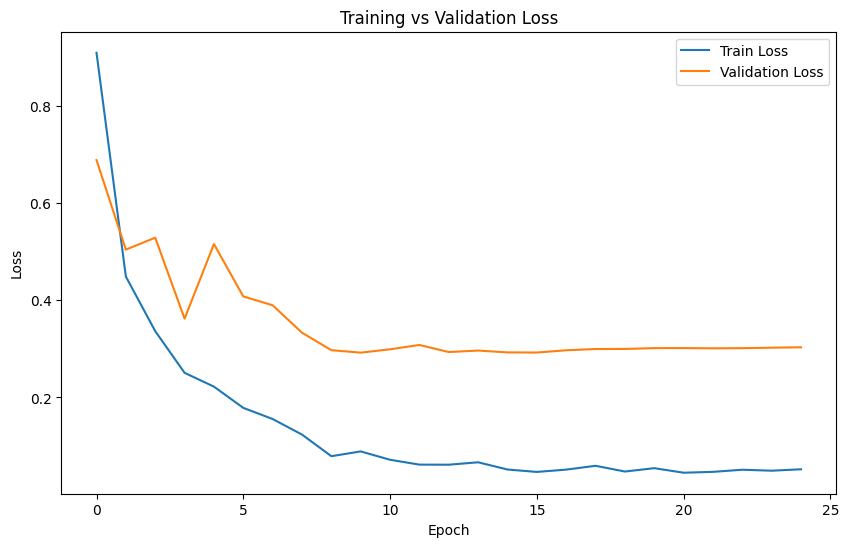

In [81]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "loss_curve.png"
    )
)


In [82]:
plt.close()

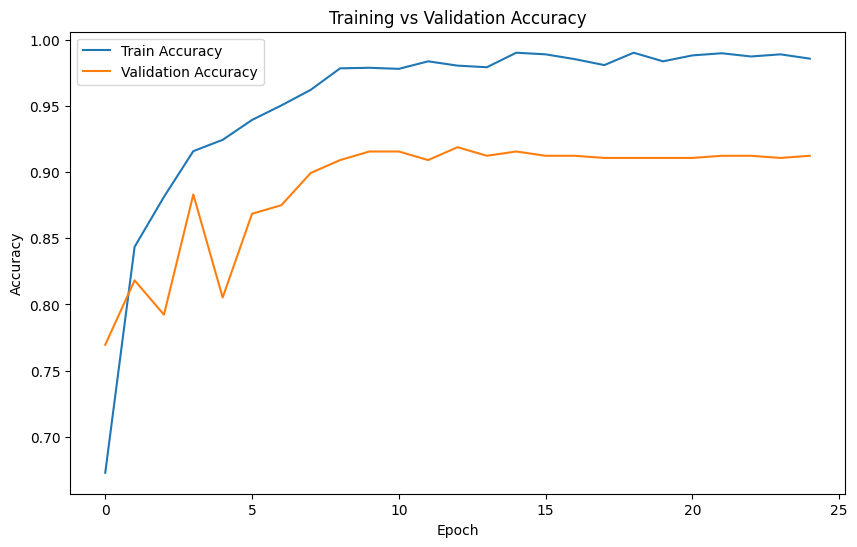

In [83]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "accuracy_curve.png"
    )
)


In [84]:

plt.close()

In [85]:
print("\nEvaluating Model...\n")

val_generator.reset()

predictions = model.predict(val_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = val_generator.classes


Evaluating Model...

20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 882ms/step


In [86]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

In [87]:
print("=" * 50)

print(f"Accuracy           : {accuracy*100:.2f}%")

print(f"Precision          : {precision*100:.2f}%")

print(f"Recall             : {recall*100:.2f}%")

print(f"F1 Score           : {f1*100:.2f}%")

print(f"MCC                : {mcc:.4f}")

print(f"Balanced Accuracy  : {balanced_acc*100:.2f}%")

print("=" * 50)


Accuracy           : 91.56%
Precision          : 91.98%
Recall             : 91.56%
F1 Score           : 91.62%
MCC                : 0.8976
Balanced Accuracy  : 90.47%


In [88]:
metrics = {

    "accuracy": float(accuracy),

    "precision": float(precision),

    "recall": float(recall),

    "f1_score": float(f1),

    "mcc": float(mcc),

    "balanced_accuracy": float(balanced_acc)
}

with open(
    os.path.join(
        RESULTS_DIR,
        "metrics.json"
    ),
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

In [89]:
report = classification_report(

    y_true,

    y_pred,

    target_names=CLASS_NAMES
)

print("\nClassification Report:\n")

print(report)

with open(
    os.path.join(
        RESULTS_DIR,
        "classification_report.txt"
    ),
    "w"
) as f:

    f.write(report)


Classification Report:

              precision    recall  f1-score   support

    Bacteria       0.97      0.98      0.98       114
       Fungi       0.90      0.92      0.91       150
     Healthy       0.75      0.97      0.85        40
    Nematode       0.92      0.79      0.85        14
        Pest       0.88      0.87      0.88       122
 Phytopthora       0.94      0.91      0.93        69
       Virus       0.98      0.89      0.93       107

    accuracy                           0.92       616
   macro avg       0.91      0.90      0.90       616
weighted avg       0.92      0.92      0.92       616



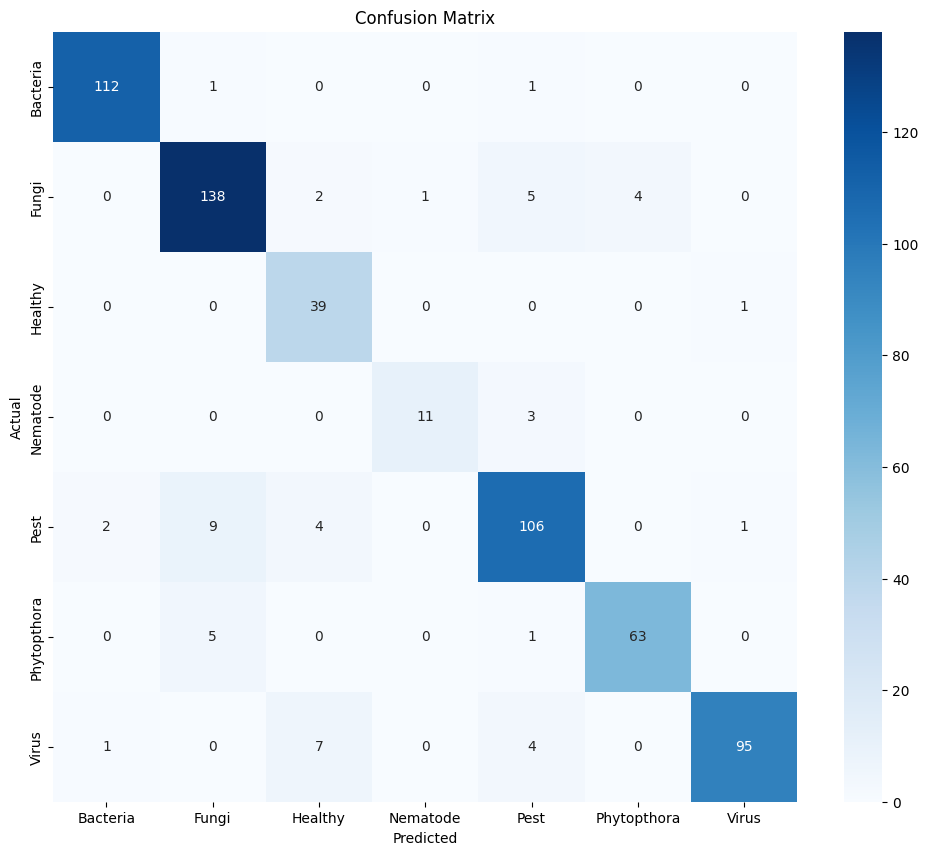

In [90]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "confusion_matrix.png"
    )
)


In [91]:

plt.close()

In [92]:
history_dict = history.history

with open(
    os.path.join(
        RESULTS_DIR,
        "history.json"
    ),
    "w"
) as f:

    json.dump(
        history_dict,
        f,
        indent=4
    )

print("\nEverything saved in /results directory")

print("\nSaved Files:")

for file in os.listdir(RESULTS_DIR):
    print(" -", file)


Everything saved in /results directory

Saved Files:
 - final.keras
 - loss_curve.png
 - metrics.json
 - history.json
 - accuracy_curve.png
 - training_log.csv
 - confusion_matrix.png
 - best.keras
 - classification_report.txt


In [93]:
train_set = set(train_paths)
val_set = set(val_paths)

print("Overlap:", len(train_set & val_set))

Overlap: 0


In [94]:
print(train_df['class'].value_counts())
print(val_df['class'].value_counts())

class
Fungi          598
Pest           489
Bacteria       455
Virus          425
Phytopthora    278
Healthy        161
Nematode        54
Name: count, dtype: int64
class
Fungi          150
Pest           122
Bacteria       114
Virus          107
Phytopthora     69
Healthy         40
Nematode        14
Name: count, dtype: int64
